# Auxiliary code

Author: João Camarneiro (for joint work with Ana Cannas da Silva)

This notebook contains some Sage code that was written in the context of the paper "Toric real loci via moment polytopes".

## 1) Smooth toric Fano varieties

In section 6, we look at smooth toric Fano $n$-folds (for $n \le 9$) and the orientability of their toric real loci. 

The code in this section uses no Sage-specific functionality, meaning that it can also be run as Python code.

### Table 2

The following code was used to generate Table 2. For each dimension $n \le 9$, it goes through the smooth toric Fano varieties of (complex) dimension $n$, and counts those that have an orientable toric real locus, using the orientability criterion of Theorem 6.1 (see also Remark 6.4 and the preceding discussion).

We are also able to partition these counts according to the Picard number of the variety. The code includes a sanity check that the "standard vertex" condition holds.

- We use Øbro's data files for dimensions $n = 2, \dots, 7$. The filenames are `Obro n=2.txt`, ..., `Obro n=7.txt`. <br>Each smooth toric Fano variety is described by giving the list of primitive inward-pointing normal vectors to the facets of the moment polytope.

In [ ]:
def orientablecounter(f):
    with open(f, 'r') as file:
        readyfornewpolytopeQ = True
        numberoffacets = None
        currentfacet = None
        dim = None
        totalcounter = 0
        sanitycheck = 0
        orientableQ = None
        orientablecounter = 0
        counterbyrank = [0]*12 #hard-coded upper bound on the Picard number (valid up to n=9 at least)
        for line in file:
            if readyfornewpolytopeQ: #start the processing of a new polytope
                numberoffacets = int(line.strip().split()[0])
                dim = int(line.strip().split()[1])
                readyfornewpolytopeQ = False
                currentfacet = 0
                sanitycheck = 0
                orientableQ = True #This flag is set to True by default, until a facet is found that violates the orientability criterion.
                totalcounter = totalcounter + 1
            else:
                currentfacet = currentfacet + 1
                v = [int(x) for x in line.strip().split()] #facet normal currently being read
                if v.count(1) == 1 and v.count(0) + v.count(1) == len(v): #check for the standard basis vectors
                    sanitycheck = sanitycheck + 1
                orientableQ = orientableQ and len([x for x in v if x % 2 != 0]) % 2 != 0
                if currentfacet == numberoffacets:
                    readyfornewpolytopeQ = True
                    if sanitycheck != dim:
                        print("Something went wrong! Assumption of vertex in standard position might not hold.")
                    if orientableQ:
                        orientablecounter = orientablecounter + 1
                        counterbyrank[numberoffacets-dim] = counterbyrank[numberoffacets-dim] + 1
    return orientablecounter, totalcounter, counterbyrank

In [ ]:
# Running the code: (adjust the file path if needed)
for n in range(2,8):
    print(f"n = {n}: {orientablecounter(f"./Fano data/Obro n={n}.txt")}")

n = 2: (1, 5, [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
n = 3: (3, 18, [0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])
n = 4: (4, 124, [0, 0, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0])
n = 5: (12, 866, [0, 1, 3, 6, 1, 1, 0, 0, 0, 0, 0, 0])
n = 6: (28, 7622, [0, 0, 6, 13, 7, 1, 1, 0, 0, 0, 0, 0])
n = 7: (85, 72256, [0, 1, 8, 41, 26, 7, 1, 1, 0, 0, 0, 0])


- We use Paffenholz's data files for dimensions $n = 7, 8, 9$. The filenames are `smooth_fano_7d.gz`, `smooth_fano_8d.gz`, and `fv-09-10p.gz`, ..., `fv-09-26p.gz`. These data files are structured differently from Øbro's, so we need separate code to process them. The $n=7$ case is covered by both sources, so it serves as a sanity check that the two functions are giving the same results.<br>Each smooth toric Fano variety is described by giving the minimal list of inequalities defining its moment polytope, using the primitive outward-pointing normal vectors of each facet.

In [ ]:
import gzip
def orientablecounterPaffenholz(filelist):
    totalcounter = 0
    orientablecounter = 0
    counterbyrank = [0]*12 #hard-coded upper bound on the Picard number (valid up to n=9 at least)
    for f in filelist:
        with gzip.open(f, 'rt') as file: #rt guarantees it reads in text mode instead of binary mode
            parsingFacetsQ = False
            numberoffacets = None
            sanitycheck = 0
            orientableQ = True #This flag is set to True by default, until a facet is found that violates the orientability criterion.
            dim = None
            for line in file:
                if not parsingFacetsQ: #start the processing of a new polytope
                    numberoffacets = 0
                    parsingFacetsQ = True
                    sanitycheck = 0
                    orientableQ = True
                    totalcounter = totalcounter + 1
                elif line.strip().split() == []: #finished looking at all the facets of the current polytope
                    if sanitycheck != dim:
                        print("Something went wrong! Assumption of vertex in standard position might not hold.")
                    parsingFacetsQ = False
                    if orientableQ:
                        orientablecounter = orientablecounter + 1
                        counterbyrank[numberoffacets-dim] = counterbyrank[numberoffacets-dim] + 1
                else: #looking at one of the facets of the current polytope
                    numberoffacets = numberoffacets + 1
                    dim = len(line.strip().split()) - 1
                    v = [int(x) for x in line.strip().split()][1:] #facet normal currently being read
                    if v.count(-1) == 1 and v.count(0) + v.count(-1) == len(v): #check for the standard basis vectors
                        sanitycheck = sanitycheck + 1
                    orientableQ = orientableQ and len([x for x in v if x % 2 != 0]) % 2 != 0
    return orientablecounter, totalcounter, counterbyrank

In [ ]:
# Running the code: (adjust the file path if needed)
print(f"n = 7: {orientablecounterPaffenholz(["./Fano data/smooth_fano_7d.gz"])}")
print(f"n = 8: {orientablecounterPaffenholz(["./Fano data/smooth_fano_8d.gz"])}")
print(f"n = 9: {orientablecounterPaffenholz([f"./Fano data/fv-09-{n}p.gz" for n in range(10,27)])}")

# Took 6m 52s to run (this might vary in different machines and setups)

n = 7: (85, 72256, [0, 1, 8, 41, 26, 7, 1, 1, 0, 0, 0, 0])
n = 8: (258, 749892, [0, 0, 13, 89, 117, 30, 7, 1, 1, 0, 0, 0])
n = 9: (896, 8229721, [0, 1, 18, 210, 444, 183, 31, 7, 1, 1, 0, 0])


### Table 3

Similarly, we can use the same data files to compute the statistical estimates explained in Remark 6.5, and which are displayed in Table 3.

In [ ]:
def orientableestimate(f):
    with open(f, 'r') as file:
        readyfornewpolytopeQ = True
        numberoffacets = None
        currentfacet = None
        dim = None
        totalcounter = 0
        orientableestimate = 0
        for line in file:
            if readyfornewpolytopeQ: #start the processing of a new polytope
                numberoffacets = int(line.strip().split()[0])
                dim = int(line.strip().split()[1])
                readyfornewpolytopeQ = False
                currentfacet = 0
                totalcounter = totalcounter + 1
                orientableestimate = orientableestimate + (1/2)**(numberoffacets-dim)
            else: #we don't need to use the facet normals
                currentfacet = currentfacet + 1
                if currentfacet == numberoffacets:
                    readyfornewpolytopeQ = True
    return orientableestimate/totalcounter*100

In [ ]:
# Running the code: (adjust the file path if needed)
for n in range(2,8):
    print(f"n = {n}: {orientableestimate(f"./Fano data/Obro n={n}.txt")} %")

n = 2: 23.75 %
n = 3: 14.930555555555555 %
n = 4: 8.225176411290322 %
n = 5: 5.145785219399538 %
n = 6: 3.286458888538114 %
n = 7: 2.1875116231697023 %


In [ ]:
import gzip
def orientableestimatePaffenholz(filelist):
    totalcounter = 0
    orientableestimate = 0
    for f in filelist:
        with gzip.open(f, 'rt') as file: #rt guarantees it reads in text mode instead of binary mode
            parsingFacetsQ = False
            numberoffacets = None
            dim = None
            for line in file:
                if not parsingFacetsQ: #start the processing of a new polytope
                    numberoffacets = 0
                    parsingFacetsQ = True
                    totalcounter = totalcounter + 1
                elif line.strip().split() == []: #finished looking at all the facets of the current polytope
                    parsingFacetsQ = False
                    orientableestimate = orientableestimate + (1/2)**(numberoffacets-dim)
                else:
                    numberoffacets = numberoffacets + 1
                    dim = len(line.strip().split()) - 1
    return orientableestimate/totalcounter*100

In [ ]:
# Running the code: (adjust the file path if needed)
print(f"n = 7: {orientableestimatePaffenholz(["./Fano data/smooth_fano_7d.gz"])} %")
print(f"n = 8: {orientableestimatePaffenholz(["./Fano data/smooth_fano_8d.gz"])} %")
print(f"n = 9: {orientableestimatePaffenholz([f"./Fano data/fv-09-{n}p.gz" for n in range(10,27)])} %")

# Took 1m 52s to run (this might vary in different machines and setups)

n = 7: 2.1875116231697023 %
n = 8: 1.4922076493044947 %
n = 9: 1.0356289227929125 %


## 2) Toric real loci in Regina

In section 8, we construct and analyze some $3$-dimensional toric real loci computationally using Regina. We also look at an example of a $4$-dimensional toric real locus in Example 6.7.

The code in this section is written in Sage (i.e. it uses functionality beyond pure Python).

### 2.1. Fan to polytope

Given the fan $\mathcal{F}$ of a smooth projective toric variety, we obtain an explicit unimodular polytope with normal fan $\mathcal{F}$. This function works in arbitrary dimensions.

This code is extracted from the source code of the Sage function [`RationalPolyhedralFan.is_polytopal`](<https://github.com/sagemath/sage/blob/develop/src/sage/geometry/fan.py#L2409>). The latter function tests whether a given fan is the normal fan of some polytope, by explicitly constructing a candidate and checking that it has the correct normal fan.

In [ ]:
def fan_to_polytope(self):
    if not self.is_complete():
        raise ValueError('to be polytopal, the fan should be complete')
    pc = PointConfiguration(self.rays())
    v_pc = [tuple(p) for p in pc]
    pc_to_indices = {tuple(p):i for i, p in enumerate(pc)}
    indices_to_vr = (tuple(r) for r in self.rays())
    cone_indices = (cone.ambient_ray_indices() for cone in self.generating_cones())
    translator = [pc_to_indices[t] for t in indices_to_vr]
    translated_cone_indices = [[translator[i] for i in ci] for ci in cone_indices]
    dc_pc = pc.deformation_cone(translated_cone_indices)
    lift = dc_pc.an_element()
    ieqs = [(lift_i,) + v for (lift_i, v) in zip(lift, v_pc)]
    poly = Polyhedron(ieqs=ieqs)

    if self.is_equivalent(poly.normal_fan()): #sanity check that should always hold true
        return poly
    else:
        print("Something went wrong!")

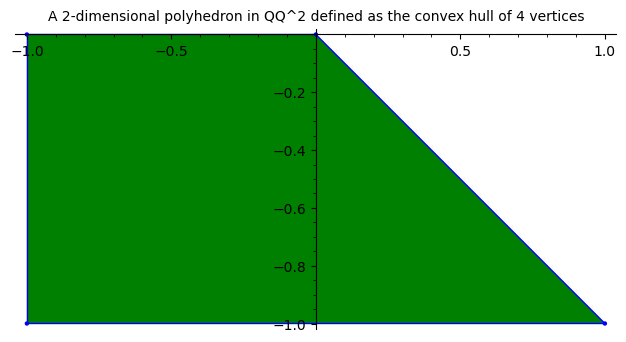

In [ ]:
# Example
f = Fan(rays=[(1,0),(0,1),(0,-1),(-1,-1)], cones=[(0,1),(0,2),(1,3),(2,3)])
fan_to_polytope(f)

### 2.2. Polytope to Regina triangulation

Given a $3$-dimensional moment polytope $\Delta$ (given as a Sage ``Polyhedron``), we pick a triangulation of $\Delta$ and construct it in Regina. Afterwards, we suitably glue together eight copies of this triangulation to obtain a Regina triangulation for the toric real locus.

In [ ]:
import regina as r
def polytope_to_Regina(poly):
    tr = poly.triangulate() #triangulation of the polytope
    T = r.Triangulation3() #initialising an empty 3d Regina triangulation
    for _ in tr:
        T.newSimplex(str(x).translate({ord(c) : None for c in ",()"})) #adds the simplices (each labelled by the set of its vertices, removing commas and brackets)

    #next step: glue this triangulation to obtain the polytope back
    tr_dict = {frozenset(simp) : i for i,simp in enumerate(tr)} #this dictionary, given a simplex of the triangulation, returns its index in the list of simplices of the triangulation
    facets_dict = {frozenset(simp) : {frozenset(x for x in simp if x != v) : i for i,v in enumerate(simp)} for simp in tr} #for each simplex in the triangulation, given three vertices of a facet triangle, 
                        #returns its index as a facet of the tetrahedron. Cf. https://regina-normal.github.io/engine-docs/classregina_1_1FaceNumbering.html for conventions on face numbering
    def aux_gluing(simplex1,simplex2,v): #this helps define the input for Perm4 below (cf. https://regina-normal.github.io/engine-docs/classregina_1_1detail_1_1SimplexBase.html#a39ac592b6db07dba1487e054be273799)
        facet = facets_dict[simplex1][simplex1.intersection(simplex2)]
        if v == facet:
            return facets_dict[simplex2][simplex1.intersection(simplex2)]
        else:
            return sorted(list(simplex2)).index(sorted(list(simplex1))[v])
    for t1,t2,_ in tr.adjacency_graph().edges(): #we loop over all (unordered) pairs of adjacent simplices in the triangulation
        T.simplex(tr_dict[t1]).join(facets_dict[t1][t1.intersection(t2)], T.simplex(tr_dict[t2]), r.Perm4([aux_gluing(t1,t2,v) for v in [0,1,2,3]])) #performing the appropriate gluings
        #cf. https://regina-normal.github.io/engine-docs/classregina_1_1detail_1_1SimplexBase.html#ad1f0a3046ec46f13f270bbc82193c5cc for details on join()

    #now, make 8 copies of the polytope
    T.makeDoubleCover()
    T.makeDoubleCover()
    T.makeDoubleCover()

    #finally, we need to glue corresponding pairs of facets in different copies of poly to form the kaleidoscope
    for tri in tr.boundary():
        simplex = frozenset([y for y in tr if set(tri).issubset(set(y))][0]) #the tetrahedron containing this boundary triangle (in the original copy of poly)
        simplex_index = tr_dict[simplex] #corresponding index in the triangulation
        normal = Polyhedron([list(tr.point_configuration()[x].affine()) for x in tri]).equations()[0][1:] #normal vector to the facet
        normal_signs = [(-1)^a for a in normal] #vector with +1 for even entries and -1 for odd entries
        def signs_to_offset(signs): #we encode the 2^n copies of poly in a binary string with n bits
            return sum(2^i for i,s in enumerate(signs) if s == -1)
        
        for iter_signs in Tuples([1,-1],3): #we iterate over the copies of poly
            comparison = vector(normal_signs).pairwise_product(vector(iter_signs)) #to which copy of poly we will glue this copy of the facet tri
            if signs_to_offset(iter_signs) < signs_to_offset(comparison): #check whether we already performed this gluing or not
                T.simplex(simplex_index + signs_to_offset(iter_signs)*len(tr)).join(facets_dict[simplex][frozenset(tri)], T.simplex(simplex_index + signs_to_offset(comparison)*len(tr)), r.Perm4(0,1,2,3)) #perform the gluing

    return T

def fan_to_Regina(fan):
    return polytope_to_Regina(fan_to_polytope(fan))

### 2.3. The examples

We analyze the toric real loci of the examples of Miyake-Oda. They will be labeled here following the list in Theorem A.1 of the paper.

In [ ]:
# List of polytopes of Miyake-Oda (more precisely, their normal fans)

def MON_fun(a,b,c,d,e):
    return [None,
       Fan(rays=[(1,0,0),(0,1,0),(0,0,1),(-1,-1,-1)],cones=[(0,1,2),(0,1,3),(0,2,3),(1,2,3)]),
       [None,
           Fan(rays=[(1,0,0),(0,1,0),(0,0,1),(0,-1,-1),(-1,-b,-c)],cones=[(0,1,2),(0,1,3),(0,2,3),(1,2,4),(1,3,4),(2,3,4)]),
           Fan(rays=[(1,0,0),(0,1,0),(0,0,1),(0,0,-1),(-1,-1,-a)],cones=[(0,1,2),(0,1,3),(0,2,4),(0,3,4),(1,2,4),(1,3,4)])
       ],
       Fan(rays=[(0,0,1),(0,0,-1),(1,0,0),(0,1,0),(-1,-a,-b),(0,-1,-c)],
           cones=[(0,2,3),(0,3,4),(0,4,5),(0,5,2),(1,2,3),(1,3,4),(1,4,5),(1,5,2)]),
       [None,
           Fan(rays=[(0,0,1),(0,0,-1),(1,0,0),(0,1,0),(-1,-a,-b),(-1,-a-1,-c),(0,-1,-d)],
               cones=[(0,2,3),(0,3,4),(0,4,5),(0,5,6),(0,6,2),(1,2,3),(1,3,4),(1,4,5),(1,5,6),(1,6,2)]),
           Fan(rays=[(1,0,0),(0,1,0),(0,0,1),(0,-1,-b),(0,0,-1),(0,1,-1),(-1,2,-1)],
               cones=[(0,1,2),(0,2,3),(0,3,4),(0,4,5),(0,5,6),(0,6,1),(1,2,6),(2,3,6),(3,4,6),(4,5,6)]) 
       ],
       [None,
           [None,
               Fan(rays=[(0,0,1),(0,0,-1),(1,0,0),(0,1,0),(-1,1-a,-b),(-1,-a,-c),(0,-1,-d),(1,-1,e)],
                   cones=[(0,2,3),(0,3,4),(0,4,5),(0,5,6),(0,6,7),(0,7,2),(1,2,3),(1,3,4),(1,4,5),(1,5,6),(1,6,7),(1,7,2)]),
               Fan(rays=[(0,0,1),(0,0,-1),(1,0,0),(0,1,0),(-1,-a,-b),(-2,-1-2*a,-c),(-1,-1-a,-d),(0,-1,e)],
                   cones=[(0,2,3),(0,3,4),(0,4,5),(0,5,6),(0,6,7),(0,7,2),(1,2,3),(1,3,4),(1,4,5),(1,5,6),(1,6,7),(1,7,2)]),
               Fan(rays=[(0,0,1),(0,0,-1),(1,0,0),(0,1,0),(-1,1-a,-b),(-1,-a,-c),(-1,-1-a,-d),(0,-1,e)],
                   cones=[(0,2,3),(0,3,4),(0,4,5),(0,5,6),(0,6,7),(0,7,2),(1,2,3),(1,3,4),(1,4,5),(1,5,6),(1,6,7),(1,7,2)])     
           ],
           Fan(rays=[(1,0,0),(0,-2,-1),(0,-1,0),(0,0,1),(0,1,b),(0,0,-1),(0,-1,-1),(-1,-3,-2)],
               cones=[(0,1,2),(0,2,3),(0,3,4),(0,4,5),(0,5,6),(0,1,7),(1,2,7),(2,3,7),(3,4,7),(4,5,7),(5,6,7),(6,0,7)]),
           Fan(rays=[(1,0,0),(0,1,0),(0,0,1),(1,0,-1),(0,0,-1),(0,-1,-2),(-1,-1,-1),(1,-1,-2)],
               cones=[(0,1,2),(0,1,3),(0,2,6),(0,3,7),(0,6,7),(1,2,6),(1,3,7),(1,4,6),(1,4,7),(4,5,6),(4,5,7),(5,6,7)]),
           Fan(rays=[(1,0,0),(0,-1,0),(0,0,1),(1,1,-b),(0,0,-1),(0,-1,-1),(-1,-2,-1),(0,1,-c)],
               cones=[(0,1,2),(0,2,3),(0,3,4),(0,4,5),(0,5,6),(0,6,1),(1,2,6),(2,7,6),(7,4,6),(4,5,6),(2,3,7),(3,4,7)])     
       ]
      ]

In [ ]:
# This function receives a (3-dimensional) fan, and prints some information about the toric real locus 
# of the associated toric symplectic manifold. If this locus is nonorientable, we analyze as well 
# the orientable double cover (this can be turned off by setting "doublecover=False").

def process_man(man,extra="",doublecover=True):
    kal = fan_to_Regina(man)
    def aux(kal,extra):
        kal.intelligentSimplify()
        sig = kal.isoSig()
        print(sig,extra)
        try:
            summands = [x for x in kal.summands()]
            print(summands)
            for c in summands:
                try:
                    print(r.StandardTriangulation.recognise(c).manifold())
                except AttributeError:
                    print("Recognition of this summand failed")
            print("")

        except r.UnsolvedCase:
            print("Connected sum decomposition algorithm did not succeed.")
            try:
                print(kal)
                print(r.StandardTriangulation.recognise(kal).manifold(), "\n")
            except AttributeError:
                print(r.StandardTriangulation.recognise(kal), "Recognition failed\n")
    aux(kal,extra)

    if doublecover and not kal.isOrientable():
        kal.makeDoubleCover()
        aux(kal,"Double cover of "+extra)

Let us explain how the output of the following cell is formatted. For example:

```
dLQbcccahqx 2(a) b=1 c=0
[<regina.Triangulation3: Closed non-orientable 3-D triangulation, f = ( 1 4 6 3 )>]
RP2 x S1
```

- `dLQbcccahqx` is the isomorphism signature of the triangulation. This can be used to reconstruct an isomorphic triangulation, e.g. using Regina's graphical interface.
- `2(a) b=1 c=0` identifies the example we are currently looking at (cf. Theorem A.1 in the paper).
- There is some basic information about the triangulation.
- `RP2 x S1` is the manifold underlying the triangulation, as identified by Regina.

The identification does not always succeed, as in the following example:
```
svLvwLwPPPQQQeflhmpplqlrqonnoqrrruagrnngcrtcassagmm 5(a) type 2 a=0 b=1 c=0 d=0 e=0
[<regina.Triangulation3: Closed non-orientable 3-D triangulation, f = ( 1 19 36 18 )>]
None
```

In other cases, the manifold is identified as a connected sum with various summands. In this case, each summand is printed in its own line. For example:
```
eLAkbccddemkic 2(b) a=1
[<regina.Triangulation3: Closed orientable 3-D triangulation, f = ( 1 3 4 2 )>, <regina.Triangulation3: Closed orientable 3-D triangulation, f = ( 1 3 4 2 )>]
RP3
RP3
```

In some instances, the connected sum decomposition algorithm fails, due to the presence of two-sided projective planes. For example:
```
mLAzwALMQbccdehgikllklrrhggrhtmmmio 5(b) b=0
Connected sum decomposition algorithm did not succeed.
Closed non-orientable 3-D triangulation, f = ( 1 13 24 12 )
None Recognition failed
```

Finally, note that some of the examples are circle bundles over surfaces, such as `Non-or, g=3/n2 x~ S1` (cf. Remark 8.6). In all cases which we are able to analyze, the obstruction constant is $b=0$, which is not explicitly displayed in the output. If we were to encounter some example with a nonzero obstruction constant $b$, the output would be, for example, of the form `SFS [Non-or, g=3/n2: (1,b)]`.

In [ ]:
# Running the examples
# Warning: this takes a long time to run completely (around 30 minutes)
# It is much faster if skipping the orientable double covers of the 5(a) examples (runs in less than 2 minutes)
# The output of this cell is saved in "output.txt"

a=0;b=0;c=0;d=0;e=0
MON = MON_fun(a,b,c,d,e)
process_man(MON[1],"1")
for b0,c0 in Tuples([0,1],2):
    b=b0;c=c0
    MON = MON_fun(a,b,c,d,e)
    process_man(MON[2][1],f"2(a) b={b} c={c}")
for a0 in [0,1]:
    a=a0
    MON = MON_fun(a,b,c,d,e)
    process_man(MON[2][2],f"2(b) a={a}")
for a0,b0,c0 in Tuples([0,1],3):
    a=a0;b=b0;c=c0
    MON = MON_fun(a,b,c,d,e)
    process_man(MON[3],f"3 a={a} b={b} c={c}")
for a0,b0,c0,d0 in Tuples([0,1],4):
    a=a0;b=b0;c=c0;d=d0
    MON = MON_fun(a,b,c,d,e)
    process_man(MON[4][1],f"4(a) a={a} b={b} c={c} d={d}")
for b0 in [0,1]:
    b=b0
    MON = MON_fun(a,b,c,d,e)
    process_man(MON[4][2],f"4(b) b={b}")
for a0,b0,c0,d0,e0 in Tuples([0,1],5):
    a=a0;b=b0;c=c0;d=d0;e=e0
    MON = MON_fun(a,b,c,d,e)
    process_man(MON[5][1][1],f"5(a) type 1 a={a} b={b} c={c} d={d} e={e}") #,doublecover=False)
for a0,b0,c0,d0,e0 in Tuples([0,1],5):
    a=a0;b=b0;c=c0;d=d0;e=e0
    MON = MON_fun(a,b,c,d,e)
    process_man(MON[5][1][2],f"5(a) type 2 a={a} b={b} c={c} d={d} e={e}") #,doublecover=False)
for a0,b0,c0,d0,e0 in Tuples([0,1],5):
    a=a0;b=b0;c=c0;d=d0;e=e0
    MON = MON_fun(a,b,c,d,e)
    process_man(MON[5][1][3],f"5(a) type 3 a={a} b={b} c={c} d={d} e={e}") #,doublecover=False)
for b0 in [0,1]:
    b=b0
    MON = MON_fun(a,b,c,d,e)
    process_man(MON[5][2],f"5(b) b={b}")
process_man(MON[5][3],"5(c)")
for b0,c0 in Tuples([0,1],2):
    b=b0;c=c0
    MON = MON_fun(a,b,c,d,e)
    process_man(MON[5][4],f"5(d) b={b} c={c}")

cMcabbgqw 1
[<regina.Triangulation3: Closed orientable 3-D triangulation, f = ( 1 3 4 2 )>]
RP3

dLQbcccahqx 2(a) b=0 c=0
[<regina.Triangulation3: Closed non-orientable 3-D triangulation, f = ( 1 4 6 3 )>]
RP2 x S1

cMcabbjaj Double cover of 2(a) b=0 c=0
[<regina.Triangulation3: Closed orientable 3-D triangulation, f = ( 1 3 4 2 )>]
S2 x S1

dLQbcccahqx 2(a) b=1 c=0
[<regina.Triangulation3: Closed non-orientable 3-D triangulation, f = ( 1 4 6 3 )>]
RP2 x S1

cMcabbjaj Double cover of 2(a) b=1 c=0
[<regina.Triangulation3: Closed orientable 3-D triangulation, f = ( 1 3 4 2 )>]
S2 x S1

dLQbcccajqs 2(a) b=0 c=1
[<regina.Triangulation3: Closed non-orientable 3-D triangulation, f = ( 1 4 6 3 )>]
RP2 x S1

dLQbcbchhcv Double cover of 2(a) b=0 c=1
[<regina.Triangulation3: Closed orientable 3-D triangulation, f = ( 1 3 4 2 )>]
S2 x S1

dLQbcccahqx 2(a) b=1 c=1
[<regina.Triangulation3: Closed non-orientable 3-D triangulation, f = ( 1 4 6 3 )>]
RP2 x S1

cMcabbjaj Double cover of 2(a) b=1 c=1
[<

### 2.4. Some additional computations

#### 2.4.1. Nondeterministic simplification

As explained at the end of Section 8, the simplification done by `intelligentSimplify()` is not fully deterministic, as it depends on random decisions. As such, some of the examples above might need to be run multiple times to obtain full information. We include those examples below, where the output shows the additional information not visible in the first attempt above.

In [ ]:
# 4(b) b=0

a=0;b=0;c=0;d=0;e=0
MON = MON_fun(a,b,c,d,e)
process_man(MON[4][2],f"4(b) b={b}", doublecover=False)

lLAPvLMQcbccdejjikikkrkjgjnnqkqkc 4(b) b=0
[<regina.Triangulation3: Closed non-orientable 3-D triangulation, f = ( 1 4 6 3 )>, <regina.Triangulation3: Closed non-orientable 3-D triangulation, f = ( 1 4 6 3 )>]
RP2 x S1
RP2 x S1



In [ ]:
# 5(d) b=0, c=0 (the other three combinations of parities follow)

# Here the connected sum decomposition algorithm fails, showing that these manifolds contain
# two-sided embedded projective planes.
# In the first attempt above, the connected sum decomposition algorithm did succeed in all these
# four cases, showing that these manifolds are prime.

a=0;b=0;c=0;d=0;e=0
MON = MON_fun(a,b,c,d,e)
process_man(MON[5][4],f"5(d) b={b} c={c}", doublecover=False)

sLLvLLQzMwPQQcejifjhjlllnoqprqrrkkkvcohfihhbgqdkuup 5(d) b=0 c=0
Connected sum decomposition algorithm did not succeed.
Closed non-orientable 3-D triangulation, f = ( 1 19 36 18 )
None Recognition failed



In [ ]:
# 5(d) b=1, c=0 (the equalities are mod 2)

a=a0;b=-1;c=0;d=d0;e=e0
MON = MON_fun(a,b,c,d,e)
process_man(MON[5][4],f"5(d) b={b} c={c}", doublecover=False)

tLLvzPALwwQMQkbdihfiiknomprqqprsssaqrqfnnsfalbjgssmfqa 5(d) b=-1 c=0
Connected sum decomposition algorithm did not succeed.
Closed non-orientable 3-D triangulation, f = ( 1 20 38 19 )
None Recognition failed



In [ ]:
# 5(d) b=0, c=1

a=0;b=0;c=1;d=0;e=0
MON = MON_fun(a,b,c,d,e)
process_man(MON[5][4],f"5(d) b={b} c={c}", doublecover=False)

sLLvLLQzMMwQQcejifjhjlllnoqrprqrkkkvcohfihhkuaxhgnd 5(d) b=0 c=1
Connected sum decomposition algorithm did not succeed.
Closed non-orientable 3-D triangulation, f = ( 1 19 36 18 )
None Recognition failed



In [ ]:
# 5(d) b=1, c=1

a=0;b=1;c=1;d=0;e=0
MON = MON_fun(a,b,c,d,e)
process_man(MON[5][4],f"5(d) b={b} c={c}", doublecover=False)

tLLvzLvLQQQzQkbdiknkmjlmnploqsrrssaqrnakxppqvccojcrpwn 5(d) b=1 c=1
Connected sum decomposition algorithm did not succeed.
Closed non-orientable 3-D triangulation, f = ( 1 20 38 19 )
None Recognition failed



#### 2.4.2. Circle bundles

In examples 4(a) and 5(a), by the considerations in the paper, we know that the toric real locus is always a circle bundle over the nonorientable surface of genus $3$ and $4$, respectively. However, through our method above, Regina is unable to precisely identify this bundle in many of the examples. More precisely, this happens when the toric real locus is nonorientable and is not a trivial product bundle.

By computing homology groups, we can see that these unidentified bundles must have obstruction constant $b=0$ (in the sense of Remark 8.6), as follows.

In [ ]:
# Here, we compute the first integral homology group of all circle bundles over the nonorientable
# surfaces of genus 3 and 4 with nonorientable total space.

for g in [3,4]:
    for type in [r.SFSpace.ClassType.n1, r.SFSpace.ClassType.n3, r.SFSpace.ClassType.n4]:
        for obs in [0,1]:
            man = r.SFSpace(type,g,0,0,0,0)
            man.insertFibre(1,obs)
            print(f"Genus {g}, type {str(type)[-2:]}, b={obs}")
            print(man.homology())
    print("")

Genus 3, type n1, b=0
3 Z + Z_2
Genus 3, type n1, b=1
3 Z
Genus 3, type n3, b=0
2 Z + 2 Z_2
Genus 3, type n3, b=1
2 Z + Z_4
Genus 3, type n4, b=0
2 Z + 2 Z_2
Genus 3, type n4, b=1
2 Z + Z_4

Genus 4, type n1, b=0
4 Z + Z_2
Genus 4, type n1, b=1
4 Z
Genus 4, type n3, b=0
3 Z + 2 Z_2
Genus 4, type n3, b=1
3 Z + Z_4
Genus 4, type n4, b=0
3 Z + 2 Z_2
Genus 4, type n4, b=1
3 Z + Z_4



In [ ]:
# Now, we compute the first integral homology groups of our examples. We conclude that they all
# have b=0 and are either of type n3 or n4.
# (this should run in less than 1 minute)

for a0,b0,c0,d0 in Tuples([0,1],4):
    a=a0;b=b0;c=c0;d=d0;e=0
    if (a==b and c!=a and d==0) or (a==b==c==d==0) or (a==1 and b==c==d==0):
        continue
    MON = MON_fun(a,b,c,d,e)
    T = fan_to_Regina(MON[4][1])
    print(f"4(a) a={a} b={b} c={c} d={d}: {T.homology()}")
print("")
for a0,b0,c0,d0,e0 in Tuples([0,1],5):
    a=a0;b=b0;c=c0;d=d0;e=e0
    if (a==c==d==0 and b==e==1) or (a==c==e==1 and b==d==0) or (b==c==d==e==0):
        continue
    MON = MON_fun(a,b,c,d,e)
    T = fan_to_Regina(MON[5][1][1])
    print(f"5(a) type 1 a={a} b={b} c={c} d={d} e={e}: {T.homology()}")
print("")
for a0,b0,c0,d0,e0 in Tuples([0,1],5):
    a=a0;b=b0;c=c0;d=d0;e=e0
    if (a==b==c==e==0 and d==1) or (a==b==1 and c==d==e==0) or (b==c==d==e==0):
        continue
    MON = MON_fun(a,b,c,d,e)
    T = fan_to_Regina(MON[5][1][2])
    print(f"5(a) type 2 a={a} b={b} c={c} d={d} e={e}: {T.homology()}")
print("")
for a0,b0,c0,d0,e0 in Tuples([0,1],5):
    a=a0;b=b0;c=c0;d=d0;e=e0
    if (a==c==e==0 and b==d==1) or (a==c==1 and b==d==e==0) or (b==c==d==e==0):
        continue
    MON = MON_fun(a,b,c,d,e)
    T = fan_to_Regina(MON[5][1][3])
    print(f"5(a) type 3 a={a} b={b} c={c} d={d} e={e}: {T.homology()}")

4(a) a=0 b=1 c=0 d=0: 2 Z + 2 Z_2
4(a) a=1 b=0 c=1 d=0: 2 Z + 2 Z_2
4(a) a=0 b=1 c=1 d=0: 2 Z + 2 Z_2
4(a) a=1 b=1 c=1 d=0: 2 Z + 2 Z_2
4(a) a=0 b=0 c=0 d=1: 2 Z + 2 Z_2
4(a) a=1 b=0 c=0 d=1: 2 Z + 2 Z_2
4(a) a=0 b=1 c=0 d=1: 2 Z + 2 Z_2
4(a) a=1 b=1 c=0 d=1: 2 Z + 2 Z_2
4(a) a=0 b=0 c=1 d=1: 2 Z + 2 Z_2
4(a) a=1 b=0 c=1 d=1: 2 Z + 2 Z_2
4(a) a=0 b=1 c=1 d=1: 2 Z + 2 Z_2
4(a) a=1 b=1 c=1 d=1: 2 Z + 2 Z_2

5(a) type 1 a=0 b=1 c=0 d=0 e=0: 3 Z + 2 Z_2
5(a) type 1 a=1 b=1 c=0 d=0 e=0: 3 Z + 2 Z_2
5(a) type 1 a=0 b=0 c=1 d=0 e=0: 3 Z + 2 Z_2
5(a) type 1 a=1 b=0 c=1 d=0 e=0: 3 Z + 2 Z_2
5(a) type 1 a=0 b=1 c=1 d=0 e=0: 3 Z + 2 Z_2
5(a) type 1 a=1 b=1 c=1 d=0 e=0: 3 Z + 2 Z_2
5(a) type 1 a=0 b=0 c=0 d=1 e=0: 3 Z + 2 Z_2
5(a) type 1 a=1 b=0 c=0 d=1 e=0: 3 Z + 2 Z_2
5(a) type 1 a=0 b=1 c=0 d=1 e=0: 3 Z + 2 Z_2
5(a) type 1 a=1 b=1 c=0 d=1 e=0: 3 Z + 2 Z_2
5(a) type 1 a=0 b=0 c=1 d=1 e=0: 3 Z + 2 Z_2
5(a) type 1 a=1 b=0 c=1 d=1 e=0: 3 Z + 2 Z_2
5(a) type 1 a=0 b=1 c=1 d=1 e=0: 3 Z + 2 Z_2
5(a) t

#### 2.4.3. Fundamental groups

Finally, we compute the fundamental groups of some of the unidentified examples.

In [ ]:
# 5(b) b=0
MON = MON_fun(0,0,0,0,0)
T52 = fan_to_Regina(MON[5][2])
print(T52.group().recogniseGroup())

FreeProduct( Z + Z_2, Z_2, Z + Z_2 )


In [ ]:
# 5(c)
MON = MON_fun(0,0,0,0,0)
T53 = fan_to_Regina(MON[5][3])
T53.simplifyExhaustive()
T53.simplifyExhaustive()
T53.simplifyExhaustive()
T53.simplifyExhaustive()
T53.simplifyExhaustive()
print(T53.group().recogniseGroup())

FreeProduct( Z + Z_2, Z + Z_2, Z_2 )


In [ ]:
# 5(d)
for b0,c0 in Tuples([0,1],2):
    b=b0;c=c0
    MON = MON_fun(a,b,c,d,e)
    T54 = fan_to_Regina(MON[5][4])
    T54.intelligentSimplify()
    print(f"b={b}, c={c}:")
    print(f"Homology: H_1 = {T54.homology(1)}")
    print(f"Fundamental group: {T54.group()}\n")

b=0, c=0:
Homology: H_1 = 2 Z + 3 Z_2
Fundamental group: < a b c d e | e^2, b c b c^-1, b e b e, c d e^-1 d^-1 c e, a e b a^-1 d^-1 b d e >

b=1, c=0:
Homology: H_1 = 2 Z + 3 Z_2
Fundamental group: < a b c d e | a^2, e^2, a e^-1 c^-1 a e c, c d e^-1 d^-1 c e, a^-1 d e d^-1 e b^-1 a b >

b=0, c=1:
Homology: H_1 = 2 Z + 3 Z_2
Fundamental group: < a b c d e | e^2, a d^-1 a b d b^-1, a d e a^-1 d e, b^-1 c^-1 e c d e b d^-1, b d b^-1 c^-1 e^-1 c d e >

b=1, c=1:
Homology: H_1 = 2 Z + 3 Z_2
Fundamental group: < a b c d e | d^2, a b a^-1 b, b^-1 c d e^-1 d e b c^-1, b c e^-1 d e b d c^-1, a^2 e^-1 d e b c d^-1 c^-1 b >



### 2.5. 4d version

This is a modified version of the code in the subsection 2.2 above, to work with $4$-dimensional polytopes instead of $3$-dimensional ones. This is applied in Example 6.7 of the paper to compute the homology of, and thus determine, the toric real locus of the smooth toric Fano fourfold $\mathbb{P}_{\mathbb{CP}^3}(\mathcal{O} \oplus \mathcal{O}(2))$ (as explained in footnote 14).

Thanks to Dima Pasechnik for the assistance with a bug in Sage found when rewriting this code (c.f. [this GitHub issue](https://github.com/sagemath/sage/issues/42142)).

In [ ]:
import regina as r
def polytope_to_Regina_4d(poly):
    tr = poly.triangulate() #triangulation of the polytope
    T = r.Triangulation4() #initialising an empty 4d Regina triangulation
    for x in tr:
        T.newSimplex(str(x).translate({ord(c) : None for c in ",()"})) #adds the simplices (each labelled by the set of its vertices, removing commas and brackets)

    #next step: glue this triangulation to obtain the polytope back
    tr_dict = {frozenset(simp) : i for i,simp in enumerate(tr)} #this dictionary, given a simplex of the triangulation, returns its index in the list of simplices of the triangulation
    facets_dict = {frozenset(simp) : {frozenset(x for x in simp if x != v) : i for i,v in enumerate(simp)} for simp in tr} #for each simplex in the triangulation, given the vertices of a facet, 
                        #returns its index as a facet of the simplex. Cf. https://regina-normal.github.io/engine-docs/classregina_1_1FaceNumbering.html for conventions on face numbering
    def aux_gluing(simplex1,simplex2,v): #this helps define the input for Perm5 below (cf. https://regina-normal.github.io/engine-docs/classregina_1_1detail_1_1SimplexBase.html#a39ac592b6db07dba1487e054be273799)
        facet = facets_dict[simplex1][simplex1.intersection(simplex2)]
        if v == facet:
            return facets_dict[simplex2][simplex1.intersection(simplex2)]
        else:
            return sorted(list(simplex2)).index(sorted(list(simplex1))[v])
    for t1,t2,_ in tr.adjacency_graph().edges(): #we loop over all (unordered) pairs of adjacent simplices in the triangulation
        T.simplex(tr_dict[t1]).join(facets_dict[t1][t1.intersection(t2)], T.simplex(tr_dict[t2]), r.Perm5([aux_gluing(t1,t2,v) for v in [0,1,2,3,4]])) #performing the appropriate gluings
        #cf. https://regina-normal.github.io/engine-docs/classregina_1_1detail_1_1SimplexBase.html#ad1f0a3046ec46f13f270bbc82193c5cc for details on join()

    #now, make 16 copies of the polytope
    T.makeDoubleCover()
    T.makeDoubleCover()
    T.makeDoubleCover()
    T.makeDoubleCover()

    #finally, we need to glue corresponding pairs of facets in different copies of poly to form the kaleidoscope
    for tri in tr.boundary():
        simplex = frozenset([y for y in tr if set(tri).issubset(set(y))][0]) #the simplex containing this boundary facet (in the original copy of poly)
        simplex_index = tr_dict[simplex] #corresponding index in the triangulation
        normal = Polyhedron([list(tr.point_configuration()[x].affine()) for x in tri]).equations()[0][1:] #normal vector to the facet
        normal_signs = [(-1)^a for a in normal] #vector with +1 for even entries and -1 for odd entries
        def signs_to_offset(signs): #we encode the 2^n copies of poly in a binary string with n bits
            return sum(2^i for i,s in enumerate(signs) if s == -1)
        
        for iter_signs in Tuples([1,-1],4): #we iterate over the copies of poly
            comparison = vector(normal_signs).pairwise_product(vector(iter_signs)) #to which copy of poly we will glue this copy of the facet tri
            if signs_to_offset(iter_signs) < signs_to_offset(comparison): #check whether we already performed this gluing or not
                T.simplex(simplex_index + signs_to_offset(iter_signs)*len(tr)).join(facets_dict[simplex][frozenset(tri)], T.simplex(simplex_index + signs_to_offset(comparison)*len(tr)), r.Perm5(0,1,2,3,4)) #perform the gluing

    return T

In [ ]:
# Applying this to the example

poly_bundle = Polyhedron(vertices=[[1,-1,-1,-1],[-1,1,-1,-1],[-1,-1,1,-1],[-1,-1,-1,-1],[-1,-1,5,1],[-1,-1,-1,1],[5,-1,-1,1],[-1,5,-1,1]])
T = polytope_to_Regina_4d(poly_bundle)
# The first and second integral homology groups of T
T.homology(1), T.homology(2)
# H_1 = Z + Z_2, H_2 = Z_2
# This implies H^2 = Z_2 by the universal coefficient theorem

(<regina.AbelianGroup: Z + Z_2>, <regina.AbelianGroup: Z_2>)